In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pylab as plt

In [2]:
transaction = pd.read_csv('train_transaction.csv')
identity = pd.read_csv('train_identity.csv')

df = pd.merge(transaction,identity,on='TransactionID',how='left')

In [3]:
df.shape

(590540, 434)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 590540 entries, 0 to 590539
Columns: 434 entries, TransactionID to DeviceInfo
dtypes: float64(399), int64(4), object(31)
memory usage: 1.9+ GB


In [5]:
df.head(10)

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M
5,2987005,0,86510,49.0,W,5937,555.0,150.0,visa,226.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,2987006,0,86522,159.0,W,12308,360.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,2987007,0,86529,422.5,W,12695,490.0,150.0,visa,226.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,2987008,0,86535,15.0,H,2803,100.0,150.0,visa,226.0,...,mobile safari 11.0,32.0,1334x750,match_status:1,T,F,F,T,mobile,iOS Device
9,2987009,0,86536,117.0,W,17399,111.0,150.0,mastercard,224.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
df['isFraud'].value_counts()

isFraud
0    569877
1     20663
Name: count, dtype: int64

In [7]:
df['isFraud'].value_counts(normalize=True)

isFraud
0    0.96501
1    0.03499
Name: proportion, dtype: float64

In [8]:
df.isnull().sum()

TransactionID          0
isFraud                0
TransactionDT          0
TransactionAmt         0
ProductCD              0
                   ...  
id_36             449555
id_37             449555
id_38             449555
DeviceType        449730
DeviceInfo        471874
Length: 434, dtype: int64

In [9]:
missing_percent = (df.isnull().sum() / len(df))*100
cols_to_drop = missing_percent[missing_percent > 50].index
df = df.drop(columns=cols_to_drop)

In [10]:
num_cols = df.select_dtypes(include=['int64','float64']).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

In [11]:
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

<Axes: >

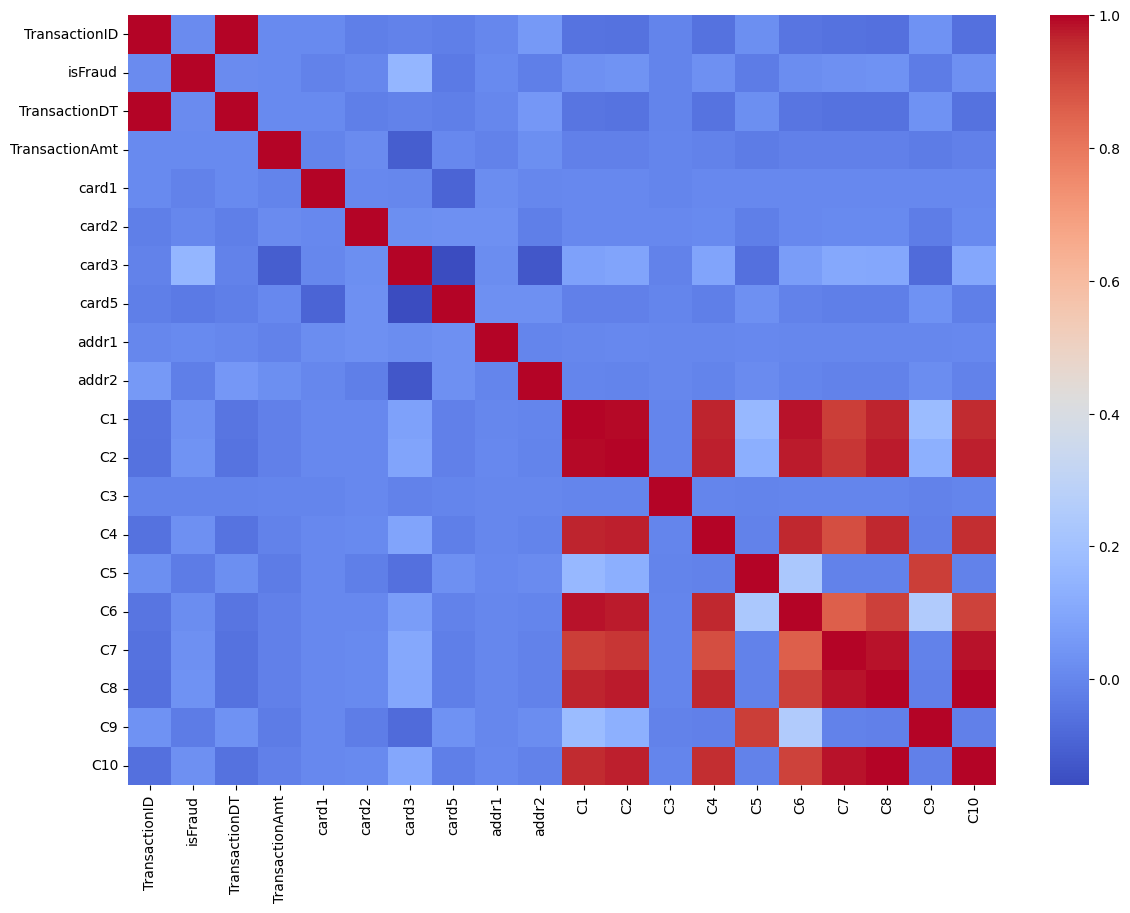

In [12]:
plt.figure(figsize=(14,10))
top20 = df.select_dtypes(include='number').iloc[:,:20]
sns.heatmap(top20.corr(),cmap='coolwarm')

In [13]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))

In [14]:
from sklearn.model_selection import train_test_split

X = df.drop('isFraud',axis=1)
y = df['isFraud']

X_train,X_test,y_train,y_test = train_test_split(X,y,random_state=42,test_size=0.2,stratify=y)

In [15]:
print(y_train.value_counts())
print(y_train.value_counts(normalize=True))

isFraud
0    455902
1     16530
Name: count, dtype: int64
isFraud
0    0.965011
1    0.034989
Name: proportion, dtype: float64


In [16]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote,y_train_smote = smote.fit_resample(X_train,y_train)

In [17]:
print(y_train_smote.value_counts())
print(y_train_smote.value_counts(normalize=True))

isFraud
0    455902
1    455902
Name: count, dtype: int64
isFraud
0    0.5
1    0.5
Name: proportion, dtype: float64


In [18]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()
X_train_smote = scaler.fit_transform(X_train_smote)
X_test = scaler.transform(X_test)

In [19]:
from sklearn.metrics import(
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

print('Training LightGBM Model...\n')

lgb_model = LGBMClassifier(n_estimators=120,learning_rate=0.05,max_depth=7,random_state=42)

lgb_model.fit(X_train_smote, y_train_smote)

lgb_pred = lgb_model.predict(X_test)
lgb_prob = lgb_model.predict_proba(X_test)[:,1]

Training LightGBM Model...

[LightGBM] [Info] Number of positive: 455902, number of negative: 455902
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.196596 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 50642
[LightGBM] [Info] Number of data points in the train set: 911804, number of used features: 216
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


c:\Users\Hriday\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Hriday\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [20]:
print("========== LIGHTGBM RESULTS ==========\n")

print("Accuracy  :", accuracy_score(y_test, lgb_pred))
print("Precision :", precision_score(y_test, lgb_pred))
print("Recall    :", recall_score(y_test, lgb_pred))
print("F1 Score  :", f1_score(y_test, lgb_pred))
print("ROC AUC   :", roc_auc_score(y_test, lgb_prob))

========== LIGHTGBM RESULTS ==========

Accuracy  : 0.9700358993463609
Precision : 0.6071428571428571
Recall    : 0.40721025889184614
F1 Score  : 0.4874728457639392
ROC AUC   : 0.88071122243954


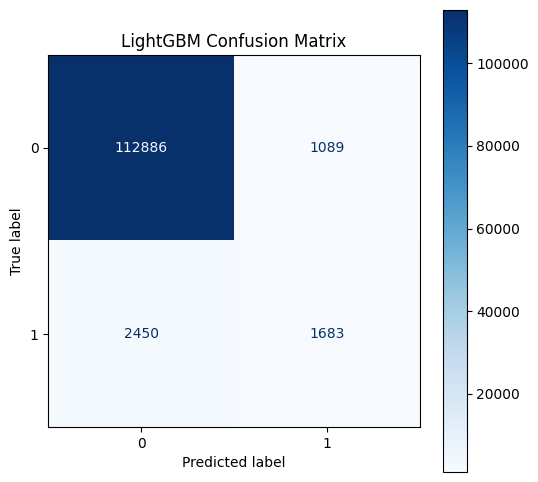

In [21]:
fig, ax = plt.subplots(figsize=(6,6))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    lgb_pred,
    cmap='Blues',
    ax=ax
)

plt.title("LightGBM Confusion Matrix")
plt.show()

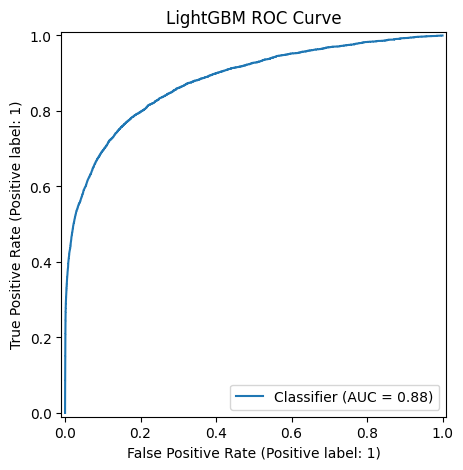

In [22]:
fig, ax = plt.subplots(figsize=(7,5))

RocCurveDisplay.from_predictions(
    y_test,
    lgb_prob,
    ax=ax
)

plt.title("LightGBM ROC Curve")
plt.show()

In [23]:
print("\nTraining XGBoost Model...\n")

xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train_smote, y_train_smote)


Training XGBoost Model...



,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [24]:
xgb_pred = xgb_model.predict(X_test)
xgb_prob = xgb_model.predict_proba(X_test)[:,1]

In [25]:
print("========== XGBOOST RESULTS ==========\n")

print("Accuracy  :", accuracy_score(y_test, xgb_pred))
print("Precision :", precision_score(y_test, xgb_pred))
print("Recall    :", recall_score(y_test, xgb_pred))
print("F1 Score  :", f1_score(y_test, xgb_pred))
print("ROC AUC   :", roc_auc_score(y_test, xgb_prob))

========== XGBOOST RESULTS ==========

Accuracy  : 0.9665306329799844
Precision : 0.5266903914590747
Recall    : 0.4297120735543189
F1 Score  : 0.4732844770153231
ROC AUC   : 0.8782285614419477


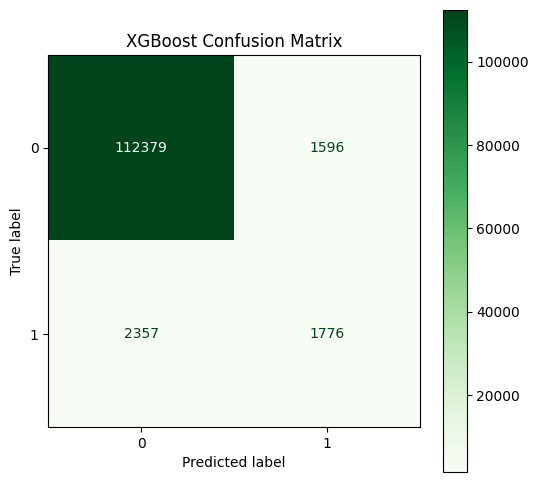

In [26]:
fig, ax = plt.subplots(figsize=(6,6))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    xgb_pred,
    cmap='Greens',
    ax=ax
)

plt.title("XGBoost Confusion Matrix")
plt.show()


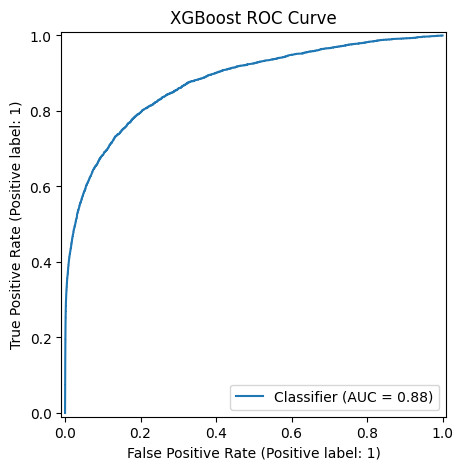

In [27]:
fig, ax = plt.subplots(figsize=(7,5))

RocCurveDisplay.from_predictions(
    y_test,
    xgb_prob,
    ax=ax
)

plt.title("XGBoost ROC Curve")
plt.show()

In [28]:
results = pd.DataFrame({

    "Model": ["LightGBM", "XGBoost"],

    "Accuracy": [
        accuracy_score(y_test, lgb_pred),
        accuracy_score(y_test, xgb_pred)
    ],

    "Precision": [
        precision_score(y_test, lgb_pred),
        precision_score(y_test, xgb_pred)
    ],

    "Recall": [
        recall_score(y_test, lgb_pred),
        recall_score(y_test, xgb_pred)
    ],

    "F1 Score": [
        f1_score(y_test, lgb_pred),
        f1_score(y_test, xgb_pred)
    ],

    "ROC AUC": [
        roc_auc_score(y_test, lgb_prob),
        roc_auc_score(y_test, xgb_prob)
    ]

})

print("\n========== MODEL COMPARISON ==========\n")
print(results)


========== MODEL COMPARISON ==========

      Model  Accuracy  Precision    Recall  F1 Score   ROC AUC
0  LightGBM  0.970036   0.607143  0.407210  0.487473  0.880711
1   XGBoost  0.966531   0.526690  0.429712  0.473284  0.878229


In [29]:
import joblib

joblib.dump(xgb_model, "fraud_detection_model.pkl")

print("\nModel saved successfully as fraud_detection_model.pkl")


Model saved successfully as fraud_detection_model.pkl


In [30]:
import shap

In [31]:
explainer = shap.TreeExplainer(lgb_model)

shap_values = explainer.shap_values(X_test)

c:\Users\Hriday\AppData\Local\Programs\Python\Python313\Lib\site-packages\shap\explainers\_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


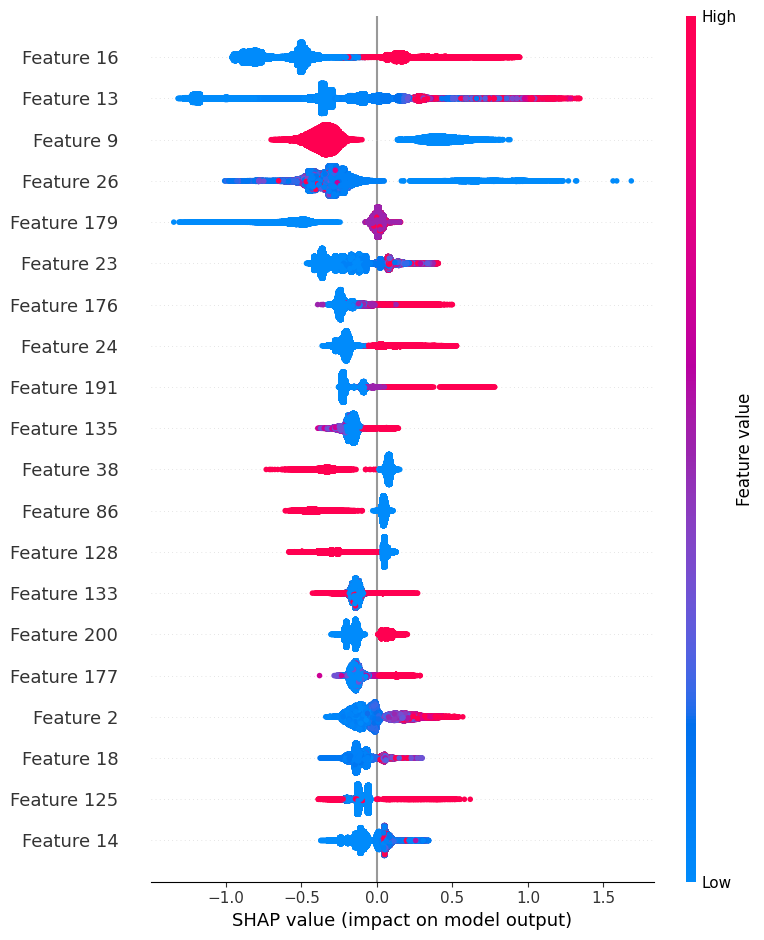

In [32]:
plt.figure(figsize=(12,8))

shap.summary_plot(
    shap_values,
    X_test,
    max_display=20
)

In [33]:
fraud_index = y_test[y_test == 1].index[0]

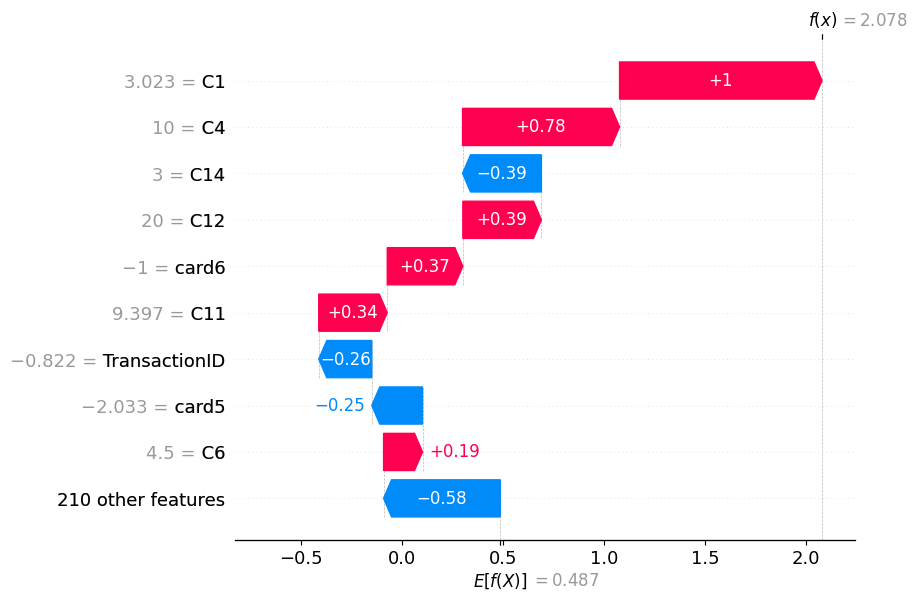

In [34]:
fraud_position = np.where(y_test.values == 1)[0][0]

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[fraud_position],
        base_values=explainer.expected_value,
        data=X_test[fraud_position],
        feature_names=df.drop('isFraud', axis=1).columns
    )
)

In [35]:
normal_index = y_test[y_test == 0].index[0]

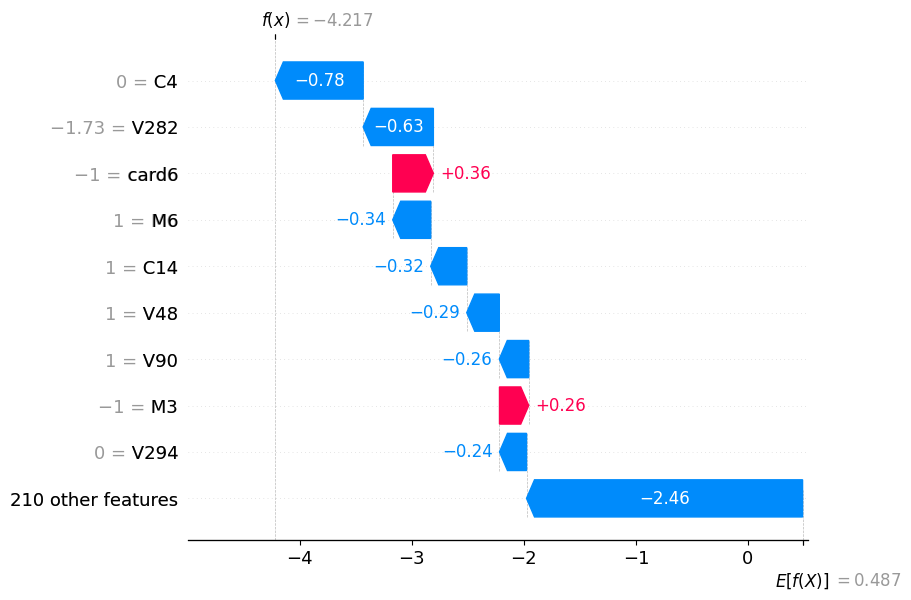

In [36]:
normal_position = np.where(y_test.values == 0)[0][0]

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[normal_position],
        base_values=explainer.expected_value,
        data=X_test[normal_position],
        feature_names=df.drop('isFraud', axis=1).columns
    )
)

In [37]:
feature_names = df.drop('isFraud', axis=1).columns

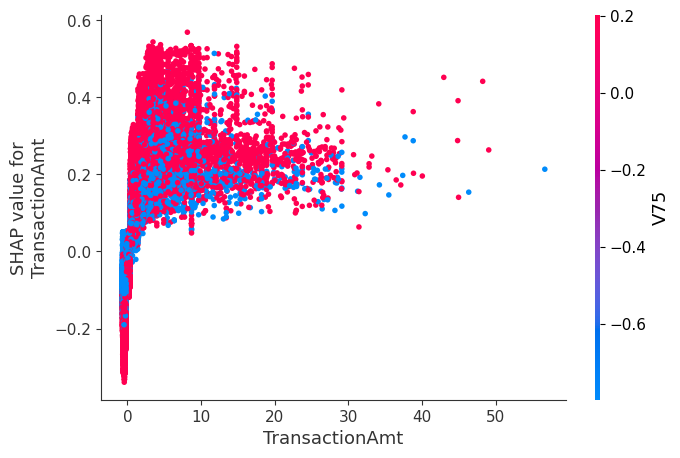

In [38]:
shap.dependence_plot(
    "TransactionAmt",
    shap_values,
    X_test,
    feature_names=feature_names
)

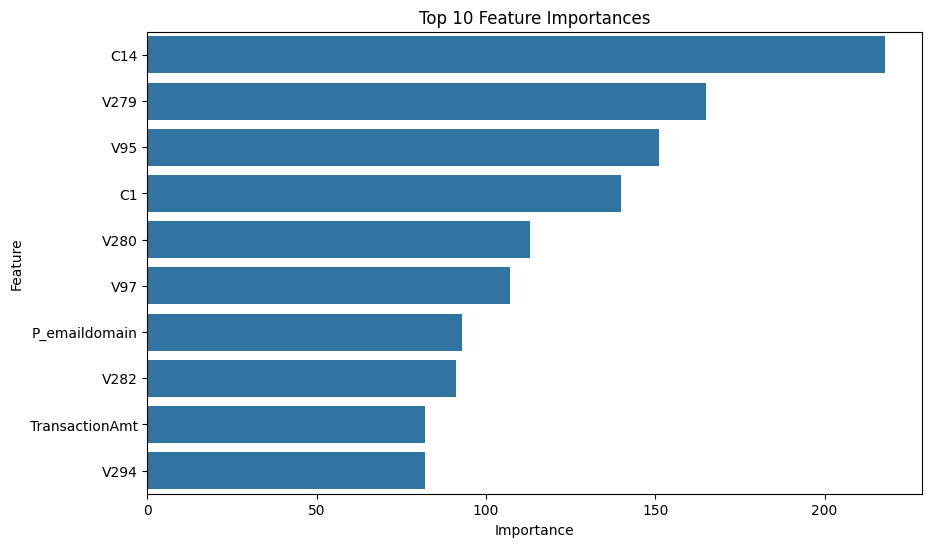

In [39]:
importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': lgb_model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=importance.head(10),
    x='Importance',
    y='Feature'
)

plt.title("Top 10 Feature Importances")
plt.show()

In [40]:
import streamlit as st
import plotly.express as px

In [41]:
st.set_page_config(
    page_title="Fraud Detection Dashboard",
    layout="wide"
)

st.title("💳 Real-Time Fraud Detection Dashboard")

2026-05-28 17:23:22.620 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-28 17:23:22.621 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-28 17:23:23.089 
  command:

    streamlit run c:\Users\Hriday\AppData\Local\Programs\Python\Python313\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-05-28 17:23:23.090 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-28 17:23:23.090 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator()

In [42]:
@st.cache_data
def load_data():

    transaction = pd.read_csv("train_transaction.csv")
    identity = pd.read_csv("train_identity.csv")

    df = pd.merge(
        transaction,
        identity,
        on="TransactionID",
        how="left"
    )

    return df


df = load_data()

2026-05-28 17:23:23.097 No runtime found, using MemoryCacheStorageManager
2026-05-28 17:23:23.098 No runtime found, using MemoryCacheStorageManager
2026-05-28 17:23:23.099 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


In [43]:
st.sidebar.header("Dashboard Filters")

sample_size = st.sidebar.slider(
    "Select Dataset Size",
    1000,
    20000,
    5000
)

df = df.sample(sample_size, random_state=42)


2026-05-28 17:23:35.124 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-28 17:23:35.125 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-28 17:23:35.125 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-28 17:23:35.126 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-28 17:23:35.126 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-28 17:23:35.127 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-28 17:23:35.127 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-28 17:23:35.128 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

In [44]:
from sklearn.ensemble import IsolationForest

print("\nTraining Isolation Forest...\n")

iso_model = IsolationForest(
    contamination=0.035,
    random_state=42
)

iso_model.fit(X_train_smote)

iso_pred = iso_model.predict(X_test)

# convert predictions
iso_pred = np.where(iso_pred == -1, 1, 0)

print("Accuracy :", accuracy_score(y_test, iso_pred))
print("Precision :", precision_score(y_test, iso_pred))
print("Recall :", recall_score(y_test, iso_pred))
print("F1 Score :", f1_score(y_test, iso_pred))


Training Isolation Forest...

Accuracy : 0.9531784468452603
Precision : 0.137519460300986
Recall : 0.06411807403822889
F1 Score : 0.08745874587458746


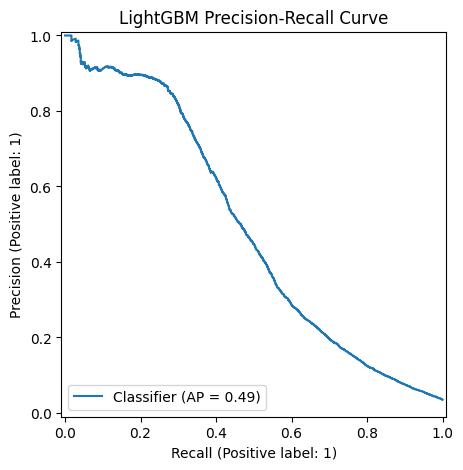

In [45]:
from sklearn.metrics import PrecisionRecallDisplay

fig, ax = plt.subplots(figsize=(7,5))

PrecisionRecallDisplay.from_predictions(
    y_test,
    lgb_prob,
    ax=ax
)

plt.title("LightGBM Precision-Recall Curve")
plt.show()

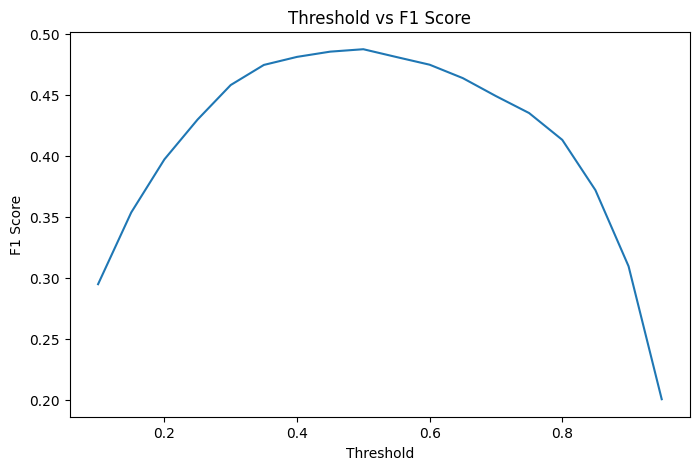

In [46]:
from sklearn.metrics import f1_score

thresholds = np.arange(0.1, 1.0, 0.05)
f1_scores = []

for thresh in thresholds:
    preds = (lgb_prob >= thresh).astype(int)
    score = f1_score(y_test, preds)
    f1_scores.append(score)

plt.figure(figsize=(8,5))
plt.plot(thresholds, f1_scores)

plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.title("Threshold vs F1 Score")
plt.show()

In [47]:
risk_df = pd.DataFrame({
    "Fraud_Probability": lgb_prob
})

risk_df["RiskTier"] = pd.cut(
    risk_df["Fraud_Probability"],
    bins=[0, 0.4, 0.75, 1],
    labels=["Clear", "Suspicious", "Critical"]
)

print(risk_df["RiskTier"].value_counts())

RiskTier
Clear         114373
Suspicious      2256
Critical        1479
Name: count, dtype: int64


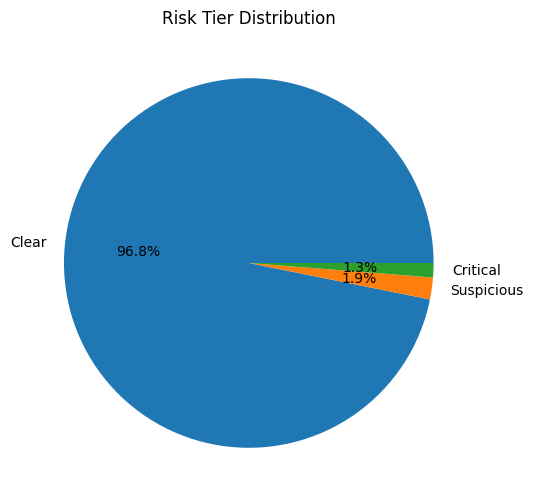

In [48]:
risk_df["RiskTier"].value_counts().plot.pie(
    autopct="%1.1f%%",
    figsize=(6,6)
)

plt.title("Risk Tier Distribution")
plt.ylabel("")
plt.show()

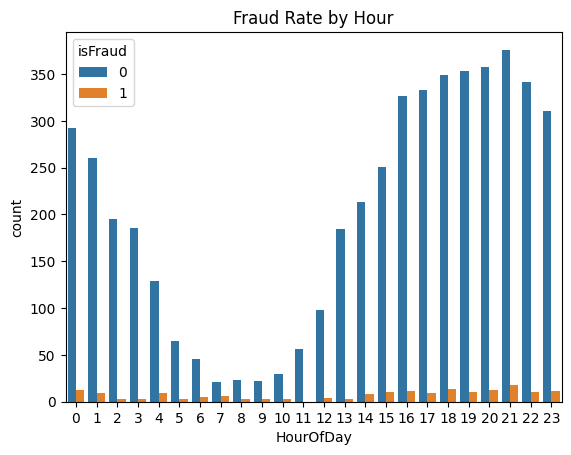

In [49]:
df["HourOfDay"] = (df["TransactionDT"] // 3600) % 24
sns.countplot(
    x=df["HourOfDay"],
    hue=df["isFraud"]
)

plt.title("Fraud Rate by Hour")
plt.show()

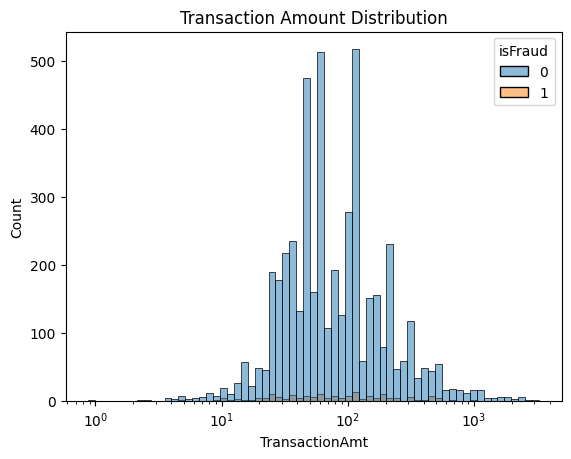

In [50]:
sns.histplot(
    data=df,
    x="TransactionAmt",
    hue="isFraud",
    log_scale=True
)

plt.title("Transaction Amount Distribution")
plt.show()